# Baseline Diffusion In-Distribution (CIFAR-10 Train/Defend testing)

This is to verify best DDPM training params to use for actual Diffusion models trained Out-of-Distribution

## Narcissus

In [8]:
import pandas as pd
import json
import numpy as np

df = pd.read_csv('/Users/sunaybhat/Documents/GitHub/Results/Poison_Defense/From_Scratch/Narcissus/Results.csv')
df['Args'] = df['Args'].apply(lambda x: json.loads(x))
df = pd.concat([df.drop(['Args'], axis=1), df['Args'].apply(pd.Series)], axis=1)

global_filters = {'noise_eps_narcissus': 16, 
                  }

# Global filters
for key, value in global_filters.items():
    df = df[df[key] == value]

# Defense filters
filters = {'Baseline':{'Data Key': 'Baseline'},
            'JPEG 25':{'Data Key': 'JPEG[25]'},
            # 'JPEG 50':{'Data Key': 'JPEG[50]'},
            # 'JPEG 75':{'Data Key': 'JPEG[75]'},
            # 'JPEG 85':{'Data Key': 'JPEG[85]'},
            # 'EBM-150':{'Data Key': 'EBM[cinic10_imagenet_ep120_nf32]_Steps[150]_T[0.0001]'},
            # 'EBM-300':{'Data Key': 'EBM[cinic10_imagenet_ep120_nf32]_Steps[300]_T[0.0001]'},
            'EBM 500':{'Data Key': 'EBM[cinic10_imagenet_ep120_nf32]_Steps[500]_T[0.0001]'},
            'HF_DDPM-10':{'Data Key': 'HF_DDPM[google_ddpm-cifar10-32]_T[10]'},
            'HF_DDPM-25':{'Data Key': 'HF_DDPM[google_ddpm-cifar10-32]_T[25]'},
            'HF_DDPM-50':{'Data Key': 'HF_DDPM[google_ddpm-cifar10-32]_T[50]'},
            'HF_DDPM-75':{'Data Key': 'HF_DDPM[google_ddpm-cifar10-32]_T[75]'},
            'HF_DDPM-100':{'Data Key': 'HF_DDPM[google_ddpm-cifar10-32]_T[100]'},
            'HF_DDPM-125':{'Data Key': 'HF_DDPM[google_ddpm-cifar10-32]_T[125]'},
            'HF_DDPM-150':{'Data Key': 'HF_DDPM[google_ddpm-cifar10-32]_T[150]'},
            'HF_DDPM-200':{'Data Key': 'HF_DDPM[google_ddpm-cifar10-32]_T[200]'},
            'DDPM[1000]_L-200':{'Data Key': 'DM_UNET[cifar10_DDPM[1000]_nf[L]_ep[200]]_T[200]'},
            'DDPM[1000]_L-150':{'Data Key': 'DM_UNET[cifar10_DDPM[1000]_nf[L]_ep[200]]_T[150]'},
            'DDPM[1000]_L-125':{'Data Key': 'DM_UNET[cifar10_DDPM[1000]_nf[L]_ep[200]]_T[125]'},
            'DDPM[1000]_L-100':{'Data Key': 'DM_UNET[cifar10_DDPM[1000]_nf[L]_ep[200]]_T[100]'},
            'DDPM[1000]_L-75':{'Data Key': 'DM_UNET[cifar10_DDPM[1000]_nf[L]_ep[200]]_T[75]'},
            'DDPM[1000]_L-50':{'Data Key': 'DM_UNET[cifar10_DDPM[1000]_nf[L]_ep[200]]_T[50]'},
            'DDPM[1000]_L-25':{'Data Key': 'DM_UNET[cifar10_DDPM[1000]_nf[L]_ep[200]]_T[25]'},
            'DDPM[1000]_L-10':{'Data Key': 'DM_UNET[cifar10_DDPM[1000]_nf[L]_ep[200]]_T[10]'},
            'DDPM[1000]_M-200':{'Data Key': 'DM_UNET[cifar10_DDPM[1000]_nf[M]_ep[150]]_T[200]'},
            'DDPM[1000]_M-150':{'Data Key': 'DM_UNET[cifar10_DDPM[1000]_nf[M]_ep[150]]_T[150]'},
            'DDPM[1000]_M-125':{'Data Key': 'DM_UNET[cifar10_DDPM[1000]_nf[M]_ep[150]]_T[125]'},
            'DDPM[1000]_M-100':{'Data Key': 'DM_UNET[cifar10_DDPM[1000]_nf[M]_ep[150]]_T[100]'},
            'DDPM[1000]_M-75':{'Data Key': 'DM_UNET[cifar10_DDPM[1000]_nf[M]_ep[150]]_T[75]'},
            'DDPM[1000]_M-50':{'Data Key': 'DM_UNET[cifar10_DDPM[1000]_nf[M]_ep[150]]_T[50]'},
            'DDPM[1000]_M-25':{'Data Key': 'DM_UNET[cifar10_DDPM[1000]_nf[M]_ep[150]]_T[25]'},
            'DDPM[1000]_M-10':{'Data Key': 'DM_UNET[cifar10_DDPM[1000]_nf[M]_ep[150]]_T[10]'},
            'DDPM[750]_L-200':{'Data Key': 'DM_UNET[cifar10_DDPM[750]_nf[L]_ep[175]]_T[200]'},
            'DDPM[750]_L-150':{'Data Key': 'DM_UNET[cifar10_DDPM[750]_nf[L]_ep[175]]_T[150]'},
            'DDPM[750]_L-125':{'Data Key': 'DM_UNET[cifar10_DDPM[750]_nf[L]_ep[175]]_T[125]'},
            'DDPM[750]_L-100':{'Data Key': 'DM_UNET[cifar10_DDPM[750]_nf[L]_ep[175]]_T[100]'},
            'DDPM[750]_L-75':{'Data Key': 'DM_UNET[cifar10_DDPM[750]_nf[L]_ep[175]]_T[75]'},
            'DDPM[750]_L-50':{'Data Key': 'DM_UNET[cifar10_DDPM[750]_nf[L]_ep[175]]_T[50]'},
            'DDPM[750]_L-25':{'Data Key': 'DM_UNET[cifar10_DDPM[750]_nf[L]_ep[175]]_T[25]'},
            'DDPM[750]_L-10':{'Data Key': 'DM_UNET[cifar10_DDPM[750]_nf[L]_ep[175]]_T[10]'},
            'DDPM[750]_M-200':{'Data Key': 'DM_UNET[cifar10_DDPM[750]_nf[M]_ep[150]]_T[200]'},
            'DDPM[750]_M-150':{'Data Key': 'DM_UNET[cifar10_DDPM[750]_nf[M]_ep[150]]_T[150]'},
            'DDPM[750]_M-125':{'Data Key': 'DM_UNET[cifar10_DDPM[750]_nf[M]_ep[150]]_T[125]'},
            'DDPM[750]_M-100':{'Data Key': 'DM_UNET[cifar10_DDPM[750]_nf[M]_ep[150]]_T[100]'},
            'DDPM[750]_M-75':{'Data Key': 'DM_UNET[cifar10_DDPM[750]_nf[M]_ep[150]]_T[75]'},
            'DDPM[750]_M-50':{'Data Key': 'DM_UNET[cifar10_DDPM[750]_nf[M]_ep[150]]_T[50]'},
            'DDPM[750]_M-25':{'Data Key': 'DM_UNET[cifar10_DDPM[750]_nf[M]_ep[150]]_T[25]'},
            'DDPM[750]_M-10':{'Data Key': 'DM_UNET[cifar10_DDPM[750]_nf[M]_ep[150]]_T[10]'},
            'DDPM[500]_L-200':{'Data Key': 'DM_UNET[cifar10_DDPM[500]_nf[L]_ep[175]]_T[200]'},
            'DDPM[500]_L-150':{'Data Key': 'DM_UNET[cifar10_DDPM[500]_nf[L]_ep[175]]_T[150]'},
            'DDPM[500]_L-125':{'Data Key': 'DM_UNET[cifar10_DDPM[500]_nf[L]_ep[175]]_T[125]'},
            'DDPM[500]_L-100':{'Data Key': 'DM_UNET[cifar10_DDPM[500]_nf[L]_ep[175]]_T[100]'},
            'DDPM[500]_L-75':{'Data Key': 'DM_UNET[cifar10_DDPM[500]_nf[L]_ep[175]]_T[75]'},
            'DDPM[500]_L-50':{'Data Key': 'DM_UNET[cifar10_DDPM[500]_nf[L]_ep[175]]_T[50]'},
            'DDPM[500]_L-25':{'Data Key': 'DM_UNET[cifar10_DDPM[500]_nf[L]_ep[175]]_T[25]'},
            'DDPM[500]_L-10':{'Data Key': 'DM_UNET[cifar10_DDPM[500]_nf[L]_ep[175]]_T[10]'},
            'DDPM[500]_M-200':{'Data Key': 'DM_UNET[cifar10_DDPM[500]_nf[M]_ep[125]]_T[200]'},
            'DDPM[500]_M-150':{'Data Key': 'DM_UNET[cifar10_DDPM[500]_nf[M]_ep[125]]_T[150]'},
            'DDPM[500]_M-125':{'Data Key': 'DM_UNET[cifar10_DDPM[500]_nf[M]_ep[125]]_T[125]'},
            'DDPM[500]_M-100':{'Data Key': 'DM_UNET[cifar10_DDPM[500]_nf[M]_ep[125]]_T[100]'},
            'DDPM[500]_M-75':{'Data Key': 'DM_UNET[cifar10_DDPM[500]_nf[M]_ep[125]]_T[75]'},
            'DDPM[500]_M-50':{'Data Key': 'DM_UNET[cifar10_DDPM[500]_nf[M]_ep[125]]_T[50]'},
            'DDPM[500]_M-25':{'Data Key': 'DM_UNET[cifar10_DDPM[500]_nf[M]_ep[125]]_T[25]'},
            'DDPM[500]_M-10':{'Data Key': 'DM_UNET[cifar10_DDPM[500]_nf[M]_ep[125]]_T[10]'},
            'DDPM[250]_L-200':{'Data Key': 'DM_UNET[cifar10_DDPM[250]_nf[L]_ep[150]]_T[200]'},
            'DDPM[250]_L-150':{'Data Key': 'DM_UNET[cifar10_DDPM[250]_nf[L]_ep[150]]_T[150]'},
            'DDPM[250]_L-125':{'Data Key': 'DM_UNET[cifar10_DDPM[250]_nf[L]_ep[150]]_T[125]'},
            'DDPM[250]_L-100':{'Data Key': 'DM_UNET[cifar10_DDPM[250]_nf[L]_ep[150]]_T[100]'},
            'DDPM[250]_L-75':{'Data Key': 'DM_UNET[cifar10_DDPM[250]_nf[L]_ep[150]]_T[75]'},
            'DDPM[250]_L-50':{'Data Key': 'DM_UNET[cifar10_DDPM[250]_nf[L]_ep[150]]_T[50]'},
            'DDPM[250]_L-25':{'Data Key': 'DM_UNET[cifar10_DDPM[250]_nf[L]_ep[150]]_T[25]'},
            'DDPM[250]_L-10':{'Data Key': 'DM_UNET[cifar10_DDPM[250]_nf[L]_ep[150]]_T[10]'},
            'DDPM[250]_M-200':{'Data Key': 'DM_UNET[cifar10_DDPM[250]_nf[M]_ep[150]]_T[200]'},
            'DDPM[250]_M-150':{'Data Key': 'DM_UNET[cifar10_DDPM[250]_nf[M]_ep[150]]_T[150]'},
            'DDPM[250]_M-125':{'Data Key': 'DM_UNET[cifar10_DDPM[250]_nf[M]_ep[150]]_T[125]'},
            'DDPM[250]_M-100':{'Data Key': 'DM_UNET[cifar10_DDPM[250]_nf[M]_ep[150]]_T[100]'},
            'DDPM[250]_M-75':{'Data Key': 'DM_UNET[cifar10_DDPM[250]_nf[M]_ep[150]]_T[75]'},
            'DDPM[250]_M-50':{'Data Key': 'DM_UNET[cifar10_DDPM[250]_nf[M]_ep[150]]_T[50]'},
            'DDPM[250]_M-25':{'Data Key': 'DM_UNET[cifar10_DDPM[250]_nf[M]_ep[150]]_T[25]'},
            'DDPM[250]_M-10':{'Data Key': 'DM_UNET[cifar10_DDPM[250]_nf[M]_ep[150]]_T[10]'},
            'DDPM[150]_L-200':{'Data Key': 'DM_UNET[cifar10_DDPM[150]_nf[L]_ep[100]]_T[200]'},
            'DDPM[150]_L-150':{'Data Key': 'DM_UNET[cifar10_DDPM[150]_nf[L]_ep[100]]_T[150]'},
            'DDPM[150]_L-125':{'Data Key': 'DM_UNET[cifar10_DDPM[150]_nf[L]_ep[100]]_T[125]'},
            'DDPM[150]_L-100':{'Data Key': 'DM_UNET[cifar10_DDPM[150]_nf[L]_ep[100]]_T[100]'},
            'DDPM[150]_L-75':{'Data Key': 'DM_UNET[cifar10_DDPM[150]_nf[L]_ep[100]]_T[75]'},
            'DDPM[150]_L-50':{'Data Key': 'DM_UNET[cifar10_DDPM[150]_nf[L]_ep[100]]_T[50]'},
            'DDPM[150]_L-25':{'Data Key': 'DM_UNET[cifar10_DDPM[150]_nf[L]_ep[100]]_T[25]'},
            'DDPM[150]_L-10':{'Data Key': 'DM_UNET[cifar10_DDPM[150]_nf[L]_ep[100]]_T[10]'},
            'DDPM[150]_M-200':{'Data Key': 'DM_UNET[cifar10_DDPM[150]_nf[M]_ep[75]]_T[200]'},
            'DDPM[150]_M-150':{'Data Key': 'DM_UNET[cifar10_DDPM[150]_nf[M]_ep[75]]_T[150]'},
            'DDPM[150]_M-125':{'Data Key': 'DM_UNET[cifar10_DDPM[150]_nf[M]_ep[75]]_T[125]'},
            'DDPM[150]_M-100':{'Data Key': 'DM_UNET[cifar10_DDPM[150]_nf[M]_ep[75]]_T[100]'},
            'DDPM[150]_M-75':{'Data Key': 'DM_UNET[cifar10_DDPM[150]_nf[M]_ep[75]]_T[75]'},
            'DDPM[150]_M-50':{'Data Key': 'DM_UNET[cifar10_DDPM[150]_nf[M]_ep[75]]_T[50]'},
            'DDPM[150]_M-25':{'Data Key': 'DM_UNET[cifar10_DDPM[150]_nf[M]_ep[75]]_T[25]'},
            'DDPM[150]_M-10':{'Data Key': 'DM_UNET[cifar10_DDPM[150]_nf[M]_ep[75]]_T[10]'},
}


df_results = []
for label, filter_dict in filters.items():

    df_filt = df
    for key, value in filter_dict.items():
        df_filt = df_filt[df_filt[key] == value]

    df_results.append({'Defense': label,
                        'Nat Acc': f"{df_filt['End Acc'].mean()*100:.2f} \u00B1 {df_filt['End Acc'].std()*100:.2f}",
                        'Poison Success': f"{df_filt['P1 Acc'].mean()*100:.2f} \u00B1 {df_filt['P1 Acc'].std()*100:.2f}",
                        'Max Poison Success': f"{df_filt['P1 Acc'].max()*100:.2f}",
                        'Poisoned Nat Acc': f"{df_filt['T1 Acc'].mean()*100:.2f} \u00B1 {df_filt['T1 Acc'].std()*100:.2f}",
                        'Num Results': len(df_filt),
                    })

df_results = pd.DataFrame(df_results)
# df_results

Text(0.5, 0.98, 'Narcissus Eps-16 Defense Results')

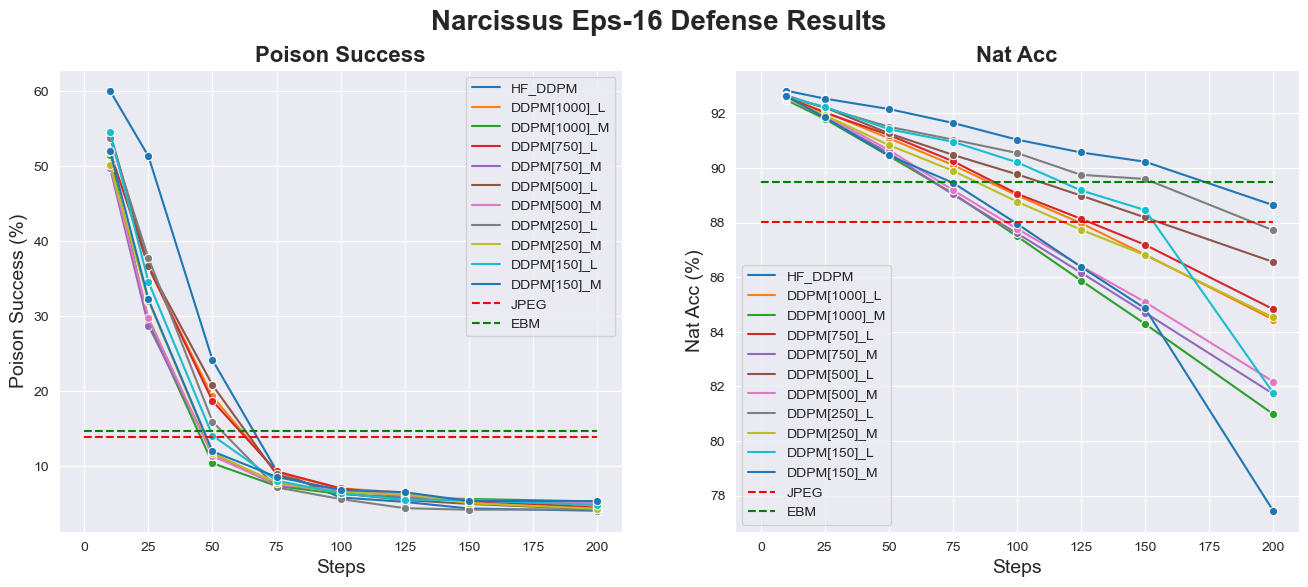

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("darkgrid")

dm_plot = df_results.copy()
dm_plot['Label'] = dm_plot['Defense'].apply(lambda x: x.split('-')[0])
dm_plot['Steps'] = dm_plot['Defense'].apply(lambda x: int(x.split('-')[1]) if len(x.split('-')) > 1 else 0)
dm_plot['Nat Acc Mean'] = dm_plot['Nat Acc'].apply(lambda x: float(x.split(' ')[0]))
dm_plot['Poison Success Mean'] = dm_plot['Poison Success'].apply(lambda x: float(x.split(' ')[0]))

# Filter out 0 steps
dm_plot_diff = dm_plot[dm_plot['Steps'] != 0]

# PLot x_axis steps, y axis Nat Acc, and hue as Label
fig,axs = plt.subplots(1, 2, figsize=(16, 6))
sns.lineplot(data=dm_plot_diff, x='Steps', y='Poison Success Mean', hue='Label', marker='o',palette='tab10',ax=axs[0])
sns.lineplot(data=dm_plot_diff, x='Steps', y='Nat Acc Mean', hue='Label', marker='o',palette='tab10',ax=axs[1])

# # Draw Hlines for EBM and JPEG
axs[0].hlines(y=dm_plot[dm_plot['Defense'] == 'JPEG 25']['Poison Success Mean'].values[0], xmin=0, xmax=200, color='r', linestyle='--', label='JPEG')
axs[0].hlines(y=dm_plot[dm_plot['Defense'] == 'EBM 500']['Poison Success Mean'].values[0], xmin=0, xmax=200, color='g', linestyle='--', label='EBM')
axs[0].legend()

axs[1].hlines(y=dm_plot[dm_plot['Defense'] == 'JPEG 25']['Nat Acc Mean'].values[0], xmin=0, xmax=200, color='r', linestyle='--', label='JPEG')
axs[1].hlines(y=dm_plot[dm_plot['Defense'] == 'EBM 500']['Nat Acc Mean'].values[0], xmin=0, xmax=200, color='g', linestyle='--', label='EBM')
axs[1].legend()

# Set titles
axs[0].set_title('Poison Success', fontsize=16, fontweight='bold')
axs[1].set_title('Nat Acc', fontsize=16, fontweight='bold')

# Set x and y labels
axs[0].set_xlabel('Steps', fontsize=14)
axs[0].set_ylabel('Poison Success (%)', fontsize=14)
axs[1].set_xlabel('Steps', fontsize=14)
axs[1].set_ylabel('Nat Acc (%)', fontsize=14)

plt.suptitle('Narcissus Eps-16 Defense Results', fontsize=20, fontweight='bold')

In [13]:
def get_train_steps(x):
    try:
        return int(x.split('[')[1].split(']')[0])
    except:
        return 'HF_DDPM'


dm_plot_diff['Defense'] = dm_plot_diff['Defense'].apply(lambda x: x.split('-')[0])
dm_plot_diff['Size'] = dm_plot_diff['Defense'].apply(lambda x: x.split('_')[1])
dm_plot_diff['Defense'] = dm_plot_diff['Defense'].apply(lambda x: x.split('_')[0])
dm_plot_diff['Train Steps'] = dm_plot_diff['Defense'].apply(get_train_steps)
dm_plot_diff['Purify Steps'] = dm_plot_diff['Steps']
pivot_table = dm_plot_diff.pivot(index=['Size','Train Steps'], columns='Purify Steps', values=['Nat Acc','Poison Success'])
# pivot_table_poison_success = dm_plot_diff.pivot(index=['Size','Train Steps'], columns='Purify Steps', values='Poison Success')


/var/folders/fc/ctj9qqms3t31k8zg1zz85xwh0000gn/T/ipykernel_53340/158848568.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dm_plot_diff['Defense'] = dm_plot_diff['Defense'].apply(lambda x: x.split('-')[0])
/var/folders/fc/ctj9qqms3t31k8zg1zz85xwh0000gn/T/ipykernel_53340/158848568.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dm_plot_diff['Size'] = dm_plot_diff['Defense'].apply(lambda x: x.split('_')[1])
/var/folders/fc/ctj9qqms3t31k8zg1zz85xwh0000gn/T/ipykernel_53340/158848568.py:10: SettingWithCo

In [14]:
pivot_table

Nat Acc                                            \
Purify Steps               10            25            50            75    
Size Train Steps                                                           
DDPM HF_DDPM      92.83 ± 0.17  92.54 ± 0.20  92.16 ± 0.20  91.65 ± 0.21   
L    150          92.60 ± 0.16  92.24 ± 0.18  91.42 ± 0.17  90.96 ± 0.15   
     250          92.66 ± 0.16     nan ± nan     nan ± nan     nan ± nan   
     500          92.61 ± 0.20  92.22 ± 0.18  91.27 ± 0.25  90.48 ± 0.21   
     750          92.57 ± 0.22  92.03 ± 0.12  91.21 ± 0.18  90.25 ± 0.12   
     1000         92.61 ± 0.18  92.05 ± 0.11  91.09 ± 0.20  90.11 ± 0.16   
M    150          92.63 ± 0.18  91.85 ± 0.12  90.46 ± 0.12  89.46 ± 0.19   
     250          92.55 ± 0.16     nan ± nan     nan ± nan     nan ± nan   
     500          92.54 ± 0.17  91.93 ± 0.14  90.66 ± 0.10  89.19 ± 0.19   
     750          92.59 ± 0.10  91.85 ± 0.13  90.55 ± 0.15  89.03 ± 0.15   
     1000         92.49 ± 0.10  91.80 ± 0.08  90.44 ± 0.18  89.07 ± 0.15   

                                                                          \
Purify Steps               100           125           150           200   
Size Train Steps                                                           
DDPM HF_DDPM      91.04 ± 0.07  90.57 ± 0.10  90.23 ± 0.19  88.64 ± 0.22   
L    150          90.21 ± 0.20  89.18 ± 0.11  88.46 ± 0.22  81.77 ± 0.23   
     250             nan ± nan     nan ± nan     nan ± nan     nan ± nan   
     500          89.77 ± 0.20  88.99 ± 0.19  88.19 ± 0.15  86.56 ± 0.19   
     750          89.06 ± 0.18  88.14 ± 0.10  87.19 ± 0.21  84.83 ± 0.22   
     1000         89.00 ± 0.25  87.98 ± 0.18  86.83 ± 0.10  84.45 ± 0.15   
M    150          87.96 ± 0.17  86.38 ± 0.11  84.86 ± 0.18  77.45 ± 0.19   
     250             nan ± nan     nan ± nan     nan ± nan     nan ± nan   
     500          87.78 ± 0.23  86.41 ± 0.13  85.09 ± 0.23  82.18 ± 0.19   
     750          87.61 ± 0.10  86.17 ± 0.25  84.70 ± 0.20  81.73 ± 0.23   
     1000         87.50 ± 0.14  85.88 ± 0.27  84.29 ± 0.12  80.99 ± 0.26   

                 Poison Success                                             \
Purify Steps                10             25             50           75    
Size Train Steps                                                             
DDPM HF_DDPM      60.09 ± 20.22  51.34 ± 27.20  24.14 ± 23.20  9.37 ± 8.33   
L    150          54.59 ± 23.77  34.57 ± 24.70  14.06 ± 10.10  8.03 ± 6.36   
     250          53.77 ± 21.77      nan ± nan      nan ± nan    nan ± nan   
     500          54.39 ± 21.38  36.66 ± 24.86  20.79 ± 18.12  8.88 ± 7.31   
     750          51.97 ± 23.43  36.61 ± 24.45  18.67 ± 16.67  9.27 ± 6.26   
     1000         54.27 ± 22.83  36.49 ± 23.28  19.29 ± 17.30  9.12 ± 6.61   
M    150          52.06 ± 25.94  32.22 ± 25.44   11.94 ± 8.22  8.53 ± 6.57   
     250          50.23 ± 26.12      nan ± nan      nan ± nan    nan ± nan   
     500          50.21 ± 27.28  29.78 ± 25.90   11.32 ± 8.42  7.53 ± 5.94   
     750          49.82 ± 25.31  28.72 ± 23.43   11.70 ± 9.91  7.38 ± 4.95   
     1000         51.54 ± 27.82  29.25 ± 25.31   10.36 ± 7.85  7.32 ± 5.61   

                                                                      
Purify Steps              100          125          150          200  
Size Train Steps                                                      
DDPM HF_DDPM      5.79 ± 6.73  5.20 ± 5.84  4.32 ± 3.80  4.02 ± 3.30  
L    150          6.36 ± 5.84  5.51 ± 4.07  5.43 ± 4.51  4.78 ± 2.79  
     250            nan ± nan    nan ± nan    nan ± nan    nan ± nan  
     500          6.34 ± 5.10  5.45 ± 4.22  4.93 ± 4.36  4.21 ± 2.32  
     750          7.01 ± 5.19  5.96 ± 4.64  5.36 ± 3.42  4.43 ± 2.48  
     1000         7.01 ± 4.82  6.43 ± 5.12  5.12 ± 3.18  4.80 ± 3.07  
M    150          6.80 ± 4.32  6.49 ± 4.24  5.33 ± 2.98  5.31 ± 2.84  
     250            nan ± nan    nan ± nan    nan ± nan    nan ± nan  
     500          6

## Neural Tangent (NTG)

In [16]:
import pandas as pd
pd.options.mode.chained_assignment = None  # default='warn'
import json
import numpy as np

df = pd.read_csv('/Users/sunaybhat/Documents/GitHub/Results/Poison_Defense/From_Scratch/NeuralTangent/Baseline_ID_DDPM.csv')

filters = {'Baseline':{'Data Key': 'Baseline'},
           'JPEG_25':{'Data Key': 'JPEG[25]'},
           'EBM_1000':{'Data Key': 'EBM[cinic10_imagenet_ep120_nf32]_Steps[1000]_T[0.0001]'},
            'HF_DDPM-200':{'Data Key': 'HF_DDPM[google/ddpm-cifar10-32]_T[200]'},
            'HF_DDPM-150':{'Data Key': 'HF_DDPM[google/ddpm-cifar10-32]_T[150]'},
            'HF_DDPM-125':{'Data Key': 'HF_DDPM[google/ddpm-cifar10-32]_T[125]'},
            'HF_DDPM-100':{'Data Key': 'HF_DDPM[google/ddpm-cifar10-32]_T[100]'}, 
            'HF_DDPM-75':{'Data Key': 'HF_DDPM[google/ddpm-cifar10-32]_T[75]'},
            'HF_DDPM-50':{'Data Key': 'HF_DDPM[google/ddpm-cifar10-32]_T[50]'},
            'HF_DDPM-25':{'Data Key': 'HF_DDPM[google/ddpm-cifar10-32]_T[25]'},
            'HF_DDPM-10':{'Data Key': 'HF_DDPM[google/ddpm-cifar10-32]_T[10]'},
            'DDPM[1000]_L-200':{'Data Key': 'DM_UNET[cifar10_DDPM[1000]_nf[L]_ep[200]]_T[200]'},
            'DDPM[1000]_L-150':{'Data Key': 'DM_UNET[cifar10_DDPM[1000]_nf[L]_ep[200]]_T[150]'},
            'DDPM[1000]_L-125':{'Data Key': 'DM_UNET[cifar10_DDPM[1000]_nf[L]_ep[200]]_T[125]'},
            'DDPM[1000]_L-100':{'Data Key': 'DM_UNET[cifar10_DDPM[1000]_nf[L]_ep[200]]_T[100]'},
            'DDPM[1000]_L-75':{'Data Key': 'DM_UNET[cifar10_DDPM[1000]_nf[L]_ep[200]]_T[75]'},
            'DDPM[1000]_L-50':{'Data Key': 'DM_UNET[cifar10_DDPM[1000]_nf[L]_ep[200]]_T[50]'},
            'DDPM[1000]_L-25':{'Data Key': 'DM_UNET[cifar10_DDPM[1000]_nf[L]_ep[200]]_T[25]'},
            'DDPM[1000]_L-10':{'Data Key': 'DM_UNET[cifar10_DDPM[1000]_nf[L]_ep[200]]_T[10]'},
            'DDPM[1000]_M-200':{'Data Key': 'DM_UNET[cifar10_DDPM[1000]_nf[M]_ep[150]]_T[200]'},
            'DDPM[1000]_M-150':{'Data Key': 'DM_UNET[cifar10_DDPM[1000]_nf[M]_ep[150]]_T[150]'},
            'DDPM[1000]_M-125':{'Data Key': 'DM_UNET[cifar10_DDPM[1000]_nf[M]_ep[150]]_T[125]'},
            'DDPM[1000]_M-100':{'Data Key': 'DM_UNET[cifar10_DDPM[1000]_nf[M]_ep[150]]_T[100]'},
            'DDPM[1000]_M-75':{'Data Key': 'DM_UNET[cifar10_DDPM[1000]_nf[M]_ep[150]]_T[75]'},
            'DDPM[1000]_M-50':{'Data Key': 'DM_UNET[cifar10_DDPM[1000]_nf[M]_ep[150]]_T[50]'},
            'DDPM[1000]_M-25':{'Data Key': 'DM_UNET[cifar10_DDPM[1000]_nf[M]_ep[150]]_T[25]'},
            'DDPM[1000]_M-10':{'Data Key': 'DM_UNET[cifar10_DDPM[1000]_nf[M]_ep[150]]_T[10]'},
            'DDPM[750]_L-200':{'Data Key': 'DM_UNET[cifar10_DDPM[750]_nf[L]_ep[175]]_T[200]'},
            'DDPM[750]_L-150':{'Data Key': 'DM_UNET[cifar10_DDPM[750]_nf[L]_ep[175]]_T[150]'},
            'DDPM[750]_L-125':{'Data Key': 'DM_UNET[cifar10_DDPM[750]_nf[L]_ep[175]]_T[125]'},
            'DDPM[750]_L-100':{'Data Key': 'DM_UNET[cifar10_DDPM[750]_nf[L]_ep[175]]_T[100]'},
            'DDPM[750]_L-75':{'Data Key': 'DM_UNET[cifar10_DDPM[750]_nf[L]_ep[175]]_T[75]'},
            'DDPM[750]_L-50':{'Data Key': 'DM_UNET[cifar10_DDPM[750]_nf[L]_ep[175]]_T[50]'},
            'DDPM[750]_L-25':{'Data Key': 'DM_UNET[cifar10_DDPM[750]_nf[L]_ep[175]]_T[25]'},
            'DDPM[750]_L-10':{'Data Key': 'DM_UNET[cifar10_DDPM[750]_nf[L]_ep[175]]_T[10]'},
            'DDPM[750]_M-200':{'Data Key': 'DM_UNET[cifar10_DDPM[750]_nf[M]_ep[150]]_T[200]'},
            'DDPM[750]_M-150':{'Data Key': 'DM_UNET[cifar10_DDPM[750]_nf[M]_ep[150]]_T[150]'},
            'DDPM[750]_M-125':{'Data Key': 'DM_UNET[cifar10_DDPM[750]_nf[M]_ep[150]]_T[125]'},
            'DDPM[750]_M-100':{'Data Key': 'DM_UNET[cifar10_DDPM[750]_nf[M]_ep[150]]_T[100]'},
            'DDPM[750]_M-75':{'Data Key': 'DM_UNET[cifar10_DDPM[750]_nf[M]_ep[150]]_T[75]'},
            'DDPM[750]_M-50':{'Data Key': 'DM_UNET[cifar10_DDPM[750]_nf[M]_ep[150]]_T[50]'},
            'DDPM[750]_M-25':{'Data Key': 'DM_UNET[cifar10_DDPM[750]_nf[M]_ep[150]]_T[25]'},
            'DDPM[750]_M-10':{'Data Key': 'DM_UNET[cifar10_DDPM[750]_nf[M]_ep[150]]_T[10]'},
            'DDPM[500]_L-200':{'Data Key': 'DM_UNET[cifar10_DDPM[500]_nf[L]_ep[175]]_T[200]'},
            'DDPM[500]_L-150':{'Data Key': 'DM_UNET[cifar10_DDPM[500]_nf[L]_ep[175]]_T[150]'},
            'DDPM[500]_L-125':{'Data Key': 'DM_UNET[cifar10_DDPM[500]_nf[L]_ep[175]]_T[125]'},
            'DDPM[500]_L-100':{'Data Key': 'DM_UNET[cifar10_DDPM[500]_nf[L]_ep[175]]_T[100]'},
            'DDPM[500]_L-75':{'Data Key': 'DM_UNET[cifar10_DDPM[500]_nf[L]_ep[175]]_T[75]'},
            'DDPM[500]_L-50':{'Data Key': 'DM_UNET[cifar10_DDPM[500]_nf[L]_ep[175]]_T[50]'},
            'DDPM[500]_L-25':{'Data Key': 'DM_UNET[cifar10_DDPM[500]_nf[L]_ep[175]]_T[25]'},
            'DDPM[500]_L-10':{'Data Key': 'DM_UNET[cifar10_DDPM[500]_nf[L]_ep[175]]_T[10]'},
            'DDPM[500]_M-200':{'Data Key': 'DM_UNET[cifar10_DDPM[500]_nf[M]_ep[125]]_T[200]'},
            'DDPM[500]_M-150':{'Data Key': 'DM_UNET[cifar10_DDPM[500]_nf[M]_ep[125]]_T[150]'},
            'DDPM[500]_M-125':{'Data Key': 'DM_UNET[cifar10_DDPM[500]_nf[M]_ep[125]]_T[125]'},
            'DDPM[500]_M-100':{'Data Key': 'DM_UNET[cifar10_DDPM[500]_nf[M]_ep[125]]_T[100]'},
            'DDPM[500]_M-75':{'Data Key': 'DM_UNET[cifar10_DDPM[500]_nf[M]_ep[125]]_T[75]'},
            'DDPM[500]_M-50':{'Data Key': 'DM_UNET[cifar10_DDPM[500]_nf[M]_ep[125]]_T[50]'},
            'DDPM[500]_M-25':{'Data Key': 'DM_UNET[cifar10_DDPM[500]_nf[M]_ep[125]]_T[25]'},
            'DDPM[500]_M-10':{'Data Key': 'DM_UNET[cifar10_DDPM[500]_nf[M]_ep[125]]_T[10]'},
            'DDPM[250]_L-200':{'Data Key': 'DM_UNET[cifar10_DDPM[250]_nf[L]_ep[150]]_T[200]'},
            'DDPM[250]_L-150':{'Data Key': 'DM_UNET[cifar10_DDPM[250]_nf[L]_ep[150]]_T[150]'},
            'DDPM[250]_L-125':{'Data Key': 'DM_UNET[cifar10_DDPM[250]_nf[L]_ep[150]]_T[125]'},
            'DDPM[250]_L-100':{'Data Key': 'DM_UNET[cifar10_DDPM[250]_nf[L]_ep[150]]_T[100]'},
            'DDPM[250]_L-75':{'Data Key': 'DM_UNET[cifar10_DDPM[250]_nf[L]_ep[150]]_T[75]'},
            'DDPM[250]_L-50':{'Data Key': 'DM_UNET[cifar10_DDPM[250]_nf[L]_ep[150]]_T[50]'},
            'DDPM[250]_L-25':{'Data Key': 'DM_UNET[cifar10_DDPM[250]_nf[L]_ep[150]]_T[25]'},
            'DDPM[250]_L-10':{'Data Key': 'DM_UNET[cifar10_DDPM[250]_nf[L]_ep[150]]_T[10]'},
            'DDPM[250]_M-200':{'Data Key': 'DM_UNET[cifar10_DDPM[250]_nf[M]_ep[150]]_T[200]'},
            'DDPM[250]_M-150':{'Data Key': 'DM_UNET[cifar10_DDPM[250]_nf[M]_ep[150]]_T[150]'},
            'DDPM[250]_M-125':{'Data Key': 'DM_UNET[cifar10_DDPM[250]_nf[M]_ep[150]]_T[125]'},
            'DDPM[250]_M-100':{'Data Key': 'DM_UNET[cifar10_DDPM[250]_nf[M]_ep[150]]_T[100]'},
            'DDPM[250]_M-75':{'Data Key': 'DM_UNET[cifar10_DDPM[250]_nf[M]_ep[150]]_T[75]'},
            'DDPM[250]_M-50':{'Data Key': 'DM_UNET[cifar10_DDPM[250]_nf[M]_ep[150]]_T[50]'},
            'DDPM[250]_M-25':{'Data Key': 'DM_UNET[cifar10_DDPM[250]_nf[M]_ep[150]]_T[25]'},
            'DDPM[250]_M-10':{'Data Key': 'DM_UNET[cifar10_DDPM[250]_nf[M]_ep[150]]_T[10]'},
            'DDPM[150]_L-200':{'Data Key': 'DM_UNET[cifar10_DDPM[150]_nf[L]_ep[100]]_T[200]'},
            'DDPM[150]_L-150':{'Data Key': 'DM_UNET[cifar10_DDPM[150]_nf[L]_ep[100]]_T[150]'},
            'DDPM[150]_L-125':{'Data Key': 'DM_UNET[cifar10_DDPM[150]_nf[L]_ep[100]]_T[125]'},
            'DDPM[150]_L-100':{'Data Key': 'DM_UNET[cifar10_DDPM[150]_nf[L]_ep[100]]_T[100]'},
            'DDPM[150]_L-75':{'Data Key': 'DM_UNET[cifar10_DDPM[150]_nf[L]_ep[100]]_T[75]'},
            'DDPM[150]_L-50':{'Data Key': 'DM_UNET[cifar10_DDPM[150]_nf[L]_ep[100]]_T[50]'},
            'DDPM[150]_L-25':{'Data Key': 'DM_UNET[cifar10_DDPM[150]_nf[L]_ep[100]]_T[25]'},
            'DDPM[150]_L-10':{'Data Key': 'DM_UNET[cifar10_DDPM[150]_nf[L]_ep[100]]_T[10]'},
            'DDPM[150]_M-200':{'Data Key': 'DM_UNET[cifar10_DDPM[150]_nf[M]]_T[200]'},
            'DDPM[150]_M-150':{'Data Key': 'DM_UNET[cifar10_DDPM[150]_nf[M]]_T[150]'},
            'DDPM[150]_M-125':{'Data Key': 'DM_UNET[cifar10_DDPM[150]_nf[M]]_T[125]'},
            'DDPM[150]_M-100':{'Data Key': 'DM_UNET[cifar10_DDPM[150]_nf[M]]_T[100]'},
            'DDPM[150]_M-75':{'Data Key': 'DM_UNET[cifar10_DDPM[150]_nf[M]]_T[75]'},
            'DDPM[150]_M-50':{'Data Key': 'DM_UNET[cifar10_DDPM[150]_nf[M]]_T[50]'},
            'DDPM[150]_M-25':{'Data Key': 'DM_UNET[cifar10_DDPM[150]_nf[M]]_T[25]'},
            'DDPM[150]_M-10':{'Data Key': 'DM_UNET[cifar10_DDPM[150]_nf[M]]_T[10]'},
}

df_results = []
for label, filter_dict in filters.items():

    df_filt = df
    for key, value in filter_dict.items():
        if value == 'NaN':
            df_filt = df_filt[df_filt[key].isnull()]
        else:
            df_filt = df_filt[df_filt[key] == value]


    df_results.append({'Defense': label,
                        'Nat Acc': f"{df_filt['End Acc'].mean()*100:.2f} \u00B1 {df_filt['End Acc'].std()*100:.2f}",
                    'Num Results': len(df_filt),
                    })
        
df_results = pd.DataFrame(df_results)

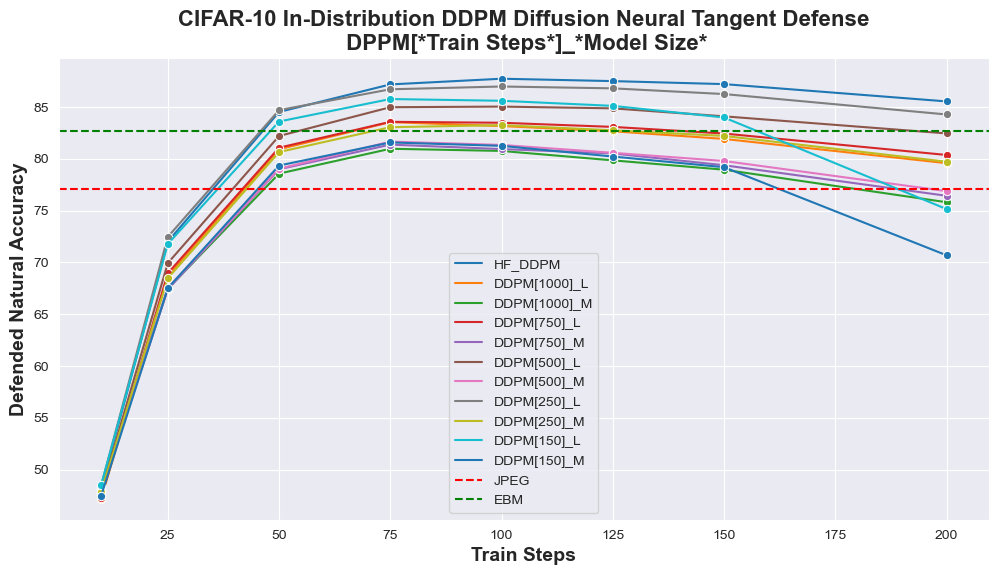

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("darkgrid")

dm_plot = df_results.copy()
dm_plot['Label'] = dm_plot['Defense'].apply(lambda x: x.split('-')[0])
dm_plot['Steps'] = dm_plot['Defense'].apply(lambda x: int(x.split('-')[1]) if len(x.split('-')) > 1 else 0)
dm_plot['Nat Acc Mean'] = dm_plot['Nat Acc'].apply(lambda x: float(x.split(' ')[0]))

# Filter out 0 steps
dm_plot_diff = dm_plot[dm_plot['Steps'] != 0]

# PLot x_axis steps, y axis Nat Acc, and hue as Label
plt.figure(figsize=(12, 6))
sns.lineplot(data=dm_plot_diff, x='Steps', y='Nat Acc Mean', hue='Label', marker='o',palette='tab10')

# Draw Hlines for EBM and JPEG and No Defense
plt.axhline(y=dm_plot[dm_plot['Defense'] == 'JPEG_25']['Nat Acc Mean'].values[0], color='r', linestyle='--', label='JPEG')
plt.axhline(y=dm_plot[dm_plot['Defense'] == 'EBM_1000']['Nat Acc Mean'].values[0], color='g', linestyle='--', label='EBM')

plt.title('CIFAR-10 In-Distribution DDPM Diffusion Neural Tangent Defense\n DPPM[*Train Steps*]_*Model Size*',fontsize=16, fontweight='bold')
plt.xlabel('Train Steps', fontsize=14, fontweight='bold')
plt.ylabel('Defended Natural Accuracy', fontsize=14, fontweight='bold')
plt.legend()

# plt.savefig('CIFAR-10 In-Distribution DDPM Diffusion Neural Tangent Defense.pdf', dpi=300,bbox_inches='tight')

In [18]:
def get_train_steps(x):
    try:
        return int(x.split('[')[1].split(']')[0])
    except:
        return 'HF_DDPM'


dm_plot_diff['Defense'] = dm_plot_diff['Defense'].apply(lambda x: x.split('-')[0])
dm_plot_diff['Size'] = dm_plot_diff['Defense'].apply(lambda x: x.split('_')[1])
dm_plot_diff['Defense'] = dm_plot_diff['Defense'].apply(lambda x: x.split('_')[0])
dm_plot_diff['Train Steps'] = dm_plot_diff['Defense'].apply(get_train_steps)
dm_plot_diff['Purify Steps'] = dm_plot_diff['Steps']
pivot_table = dm_plot_diff.pivot(index=['Size','Train Steps'], columns='Purify Steps', values='Nat Acc')
print(pivot_table.to_latex())

\begin{tabular}{llllllllll}
\toprule
  & Purify Steps &           10  &           25  &           50  &           75  &           100 &           125 &           150 &           200 \\
Size & Train Steps &               &               &               &               &               &               &               &               \\
\midrule
DDPM & HF\_DDPM &  48.18 ± 0.59 &  72.00 ± 0.37 &  84.52 ± 0.38 &  87.18 ± 0.27 &  87.73 ± 0.32 &  87.50 ± 0.37 &  87.21 ± 0.16 &  85.54 ± 0.31 \\
L & 150 &  48.50 ± 0.66 &  71.78 ± 0.42 &  83.60 ± 0.29 &  85.77 ± 0.18 &  85.60 ± 0.34 &  85.11 ± 0.22 &  83.99 ± 0.33 &  75.15 ± 0.40 \\
  & 250 &  48.43 ± 0.32 &  72.46 ± 0.35 &  84.70 ± 0.34 &  86.71 ± 0.29 &  86.98 ± 0.28 &  86.80 ± 0.20 &  86.25 ± 0.25 &  84.28 ± 0.45 \\
  & 500 &  47.85 ± 0.51 &  69.93 ± 0.41 &  82.20 ± 0.32 &  84.98 ± 0.39 &  85.04 ± 0.32 &  84.87 ± 0.18 &  84.10 ± 0.15 &  82.45 ± 0.38 \\
  & 750 &  47.30 ± 0.72 &  68.95 ± 0.48 &  81.07 ± 0.34 &  83.57 ± 0.20 &  83.48 ± 0.27 &  8

/var/folders/fc/ctj9qqms3t31k8zg1zz85xwh0000gn/T/ipykernel_27869/1522933308.py:14: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  print(pivot_table.to_latex())
